In [361]:
from datetime import datetime
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from  statsmodels.tsa.stattools import adfuller
from sklearn.model_selection import train_test_split
from pmdarima import auto_arima
from pmdarima.arima import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error

In [4]:
df = pd.read_csv('./data/GOOGL_2006-01-01_to_2018-01-01.csv')

In [5]:
df = df.drop('Open', axis= 1)

In [6]:
df.head()

,Date,High,Low,Close,Volume,Name
0,2006-01-03,218.05,209.32,217.83,13137450,GOOGL
1,2006-01-04,224.70,220.09,222.84,15292353,GOOGL
2,2006-01-05,226.00,220.97,225.85,10815661,GOOGL
3,2006-01-06,235.49,226.85,233.06,17759521,GOOGL
4,2006-01-09,236.94,230.70,233.68,12795837,GOOGL


([<matplotlib.axis.XTick at 0x2677012c400>,
 [Text(0, 0, '2006-01-03'),
  Text(300, 0, '2007-03-15'),
  Text(600, 0, '2008-05-22'),
  Text(900, 0, '2009-07-31'),
  Text(1200, 0, '2010-10-11'),
  Text(1500, 0, '2011-12-16'),
  Text(1800, 0, '2013-03-01'),
  Text(2100, 0, '2014-05-09'),
  Text(2400, 0, '2015-07-20'),
  Text(2700, 0, '2016-09-26'),
  Text(3000, 0, '2017-12-04')])

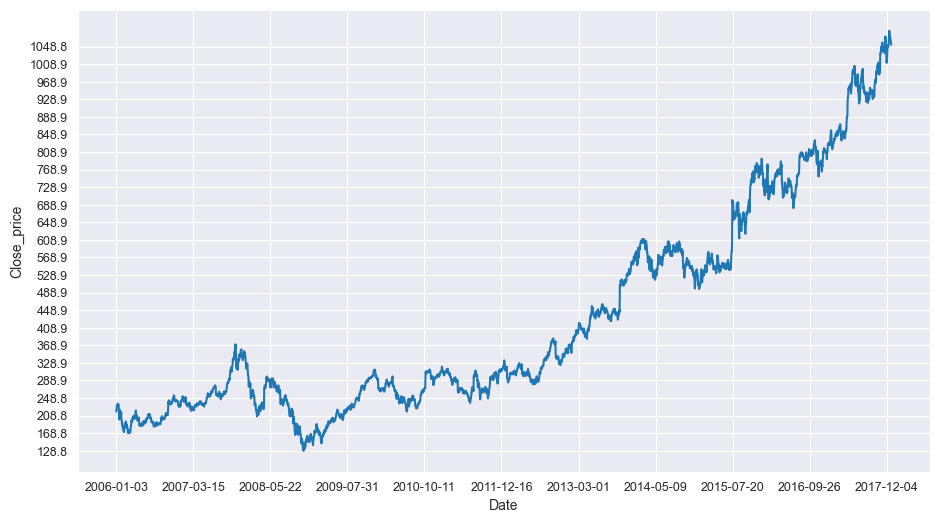

In [7]:
plt.figure(figsize= (11,6))
plt.plot(df['Date'], df['Close'])
plt.xlabel('Date')
plt.ylabel('Close_price')
plt.yticks(np.arange(df['Close'].min(), df['Close'].max(), 40),size = 9)
plt.xticks([ i for i in range(0,df.count()[0],300) ], size = 9)

Let's start our analysis with decomposition of the time series (ts)

In [8]:
decompose = seasonal_decompose( x = df['Close'].values, model = 'additive', period=800)

In [9]:
season = decompose.seasonal
trends = decompose.trend
noise = decompose.resid

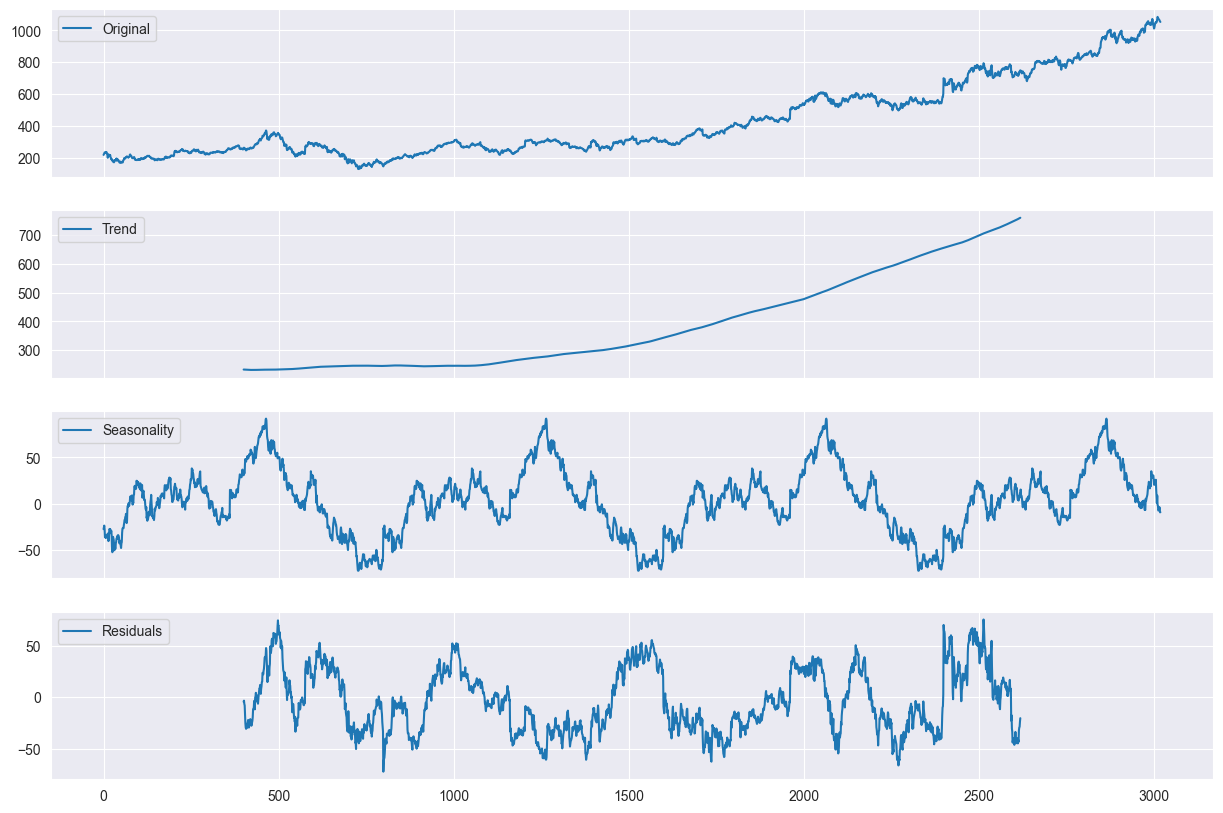

In [10]:
fig, axes = plt.subplots(4, 1, sharex=True, sharey=False)
fig.set_figheight(10)
fig.set_figwidth(15)

axes[0].plot(df['Close'].values, label='Original')
axes[0].legend(loc='upper left');

axes[1].plot(trends, label='Trend')
axes[1].legend(loc='upper left');

axes[2].plot(season, label='Seasonality')
axes[2].legend(loc='upper left');

axes[3].plot(noise, label='Residuals')
axes[3].legend(loc='upper left');

Looking at this decomposition we can see seasonal behavior of the ts, its trend and residuals (or noise)

Now let us have a look at the autocorrelation
From this we will derive, how far the next value depends on the previos one

In [107]:
df_new = df[['Date','Close']]
df_new.set_index('Date', inplace=True)

In [108]:
df_new['log'] = np.log(df_new['Close'])

C:\Users\1\AppData\Local\Temp\ipykernel_7260\2999233326.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['log'] = np.log(df_new['Close'])


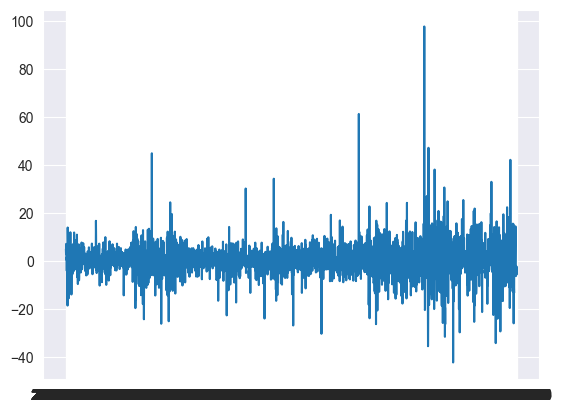

In [109]:
plt.plot(df_new['Close'].diff())

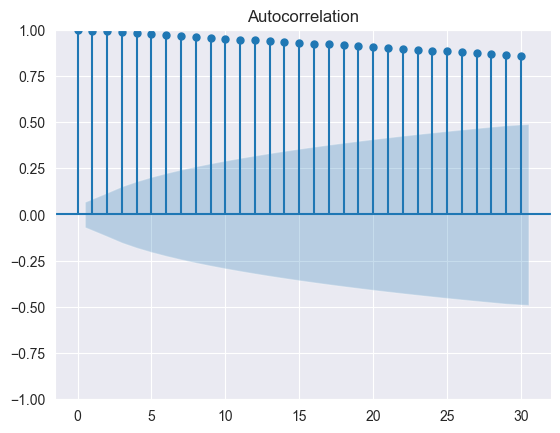

In [213]:
plot_acf(np.log(df_new['Close'][2200:]))
plt.show()

C:\PyCharm_Prjs\course_prj\venv\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


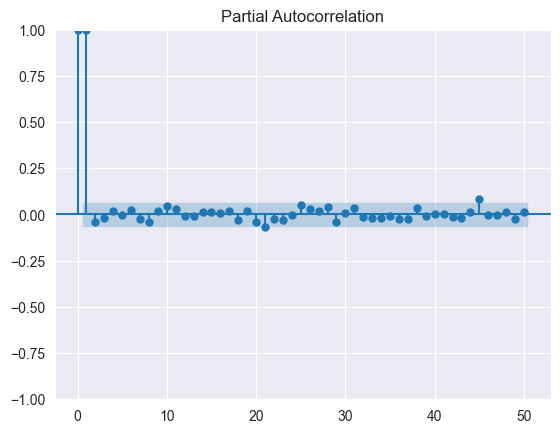

In [214]:
plot_pacf(df_new['Close'][2200:], lags = 50)
plt.show()

From the autocorr. and partial autocorr. we see obtain p and q values for the following ARIMA model. Then p is about 50-60, q is 2

Now, lets conduct the Augmented Dickey-Fuller test (ADF) and Jarque-Bera test (JB)
So, the ADF is needed to decide whether our ts is stationary or not.
Another, features ,proving nonstationarity of a ts, are differencing mean value and variance


In [ ]:
adf_test = adfuller(df['Close'].values)

print('ADF:', adf_test[0])
print('p-value:', adf_test[1])

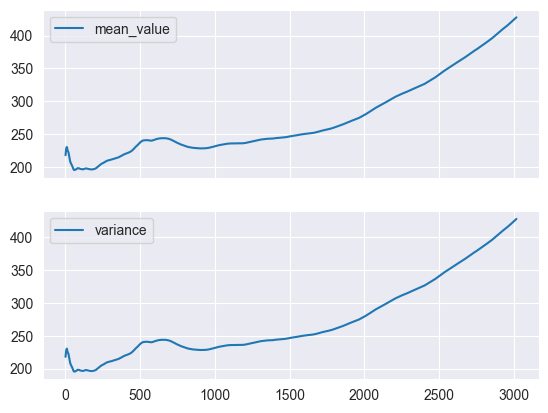

In [303]:
ig, axes = plt.subplots(2, 1, sharex=True, sharey=False)
fig.set_figheight(20)
fig.set_figwidth(15)

axes[0].plot(list(np.mean(df['Close'][:i]) for i in range (0,len(df['Close'].values))), label = 'mean_value')
axes[0].legend(loc='upper left');
axes[1].plot(list(np.mean(df['Close'][:i]) for i in range (0,len(df['Close'].values))), label = 'variance')
axes[1].legend(loc='upper left');

In [381]:
rolling_mean = df['Close'].rolling(window = 12).mean()
df['rolling_mean_diff'] = rolling_mean - rolling_mean.shift()

In [405]:
auto_arima(df['Close'].dropna()[2000:], start_p=1, start_Q=1,
                      test='adf',       # use adftest to find optimal 'd'
                      max_p=3, max_q=3, # maximum p and q
                      m=1,              # frequency of series
                      d=None,           # let model determine 'd'
                      seasonal=True,   # No Seasonality
                      D=0,
                      trace=True,
                      error_action='ignore',
                      suppress_warnings=True,
                      stepwise=True).summary()

Performing stepwise search to minimize aic
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=7460.748, Time=0.80 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=7462.254, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=7461.757, Time=0.09 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=7461.809, Time=0.20 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=7463.263, Time=0.02 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=7463.576, Time=0.15 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=7463.743, Time=0.23 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=7461.918, Time=0.64 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=7460.160, Time=0.38 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=7462.828, Time=0.24 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=7462.140, Time=0.56 sec
 ARIMA(1,1,3)(0,0,0)[0]             : AIC=7462.389, Time=0.25 sec

Best model:  ARIMA(1,1,3)(0,0,0)[0] intercept
Total fit time: 3.619 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1019
Model:               SARIMAX(1, 1, 3)   Log Likelihood               -3724.080
Date:                Tue, 08 Nov 2022   AIC                           7460.160
Time:                        00:19:34   BIC                           7489.713
Sample:                             0   HQIC                          7471.382
                               - 1019                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.1322      0.095      1.390      0.165      -0.054       0.319
ar.L1          0.7423      0.139      5.351      0.000       0.470       1.014
ma.L1         -0.6986      0.144     -4.863      0.000      -0.980      -0.417
ma.L2         -0.0242      0.039     -0.627      0.531      -0.100       0.052
ma.L3         -0.0658      0.033     -2.010      0.044      -0.130      -0.002
sigma2        88.1069      1.687     52.227      0.000      84.801      91.413
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              7632.67
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               1.44   Skew:                             1.01
Prob(H) (two-sided):                  0.00   Kurtosis:                        16.26
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

The more negative value of ADF and the closer p-value to 0 is, the more condfident one can be that the ts is stationary and vice versa.
So, from the results it is clear that we deal with nonstationary ts. After that we can construct the ARIMA model.

In [406]:
model = SARIMAX(df['Close'], order=(1, 1, 3))

In [407]:
arima = model.fit()

In [408]:
df.tail()

,Date,High,Low,Close,Volume,Name,rolling_mean_diff
3014,2017-12-22,1071.72,1067.64,1068.86,889446,GOOGL,3.011667
3015,2017-12-26,1068.86,1058.64,1065.85,918767,GOOGL,1.773333
3016,2017-12-27,1068.27,1058.38,1060.20,1116203,GOOGL,0.901667
3017,2017-12-28,1064.84,1053.38,1055.95,994249,GOOGL,0.331667
3018,2017-12-29,1058.05,1052.70,1053.40,1180340,GOOGL,0.385833


In [411]:
predicts = arima.predict(start = 2800, end = 3018)#len(df) - int(len(df)*0.8)-1
#predicts_1 = fit_arima.predict(start = 0, end = int(len(df)*0.8)-1)
print(int(len(df)*0.8)-1)
print(len(df))

2414
3019


([<matplotlib.axis.XTick at 0x26716b0f790>,
 [Text(0, 0, '0'), Text(90, 0, '90'), Text(180, 0, '180')])

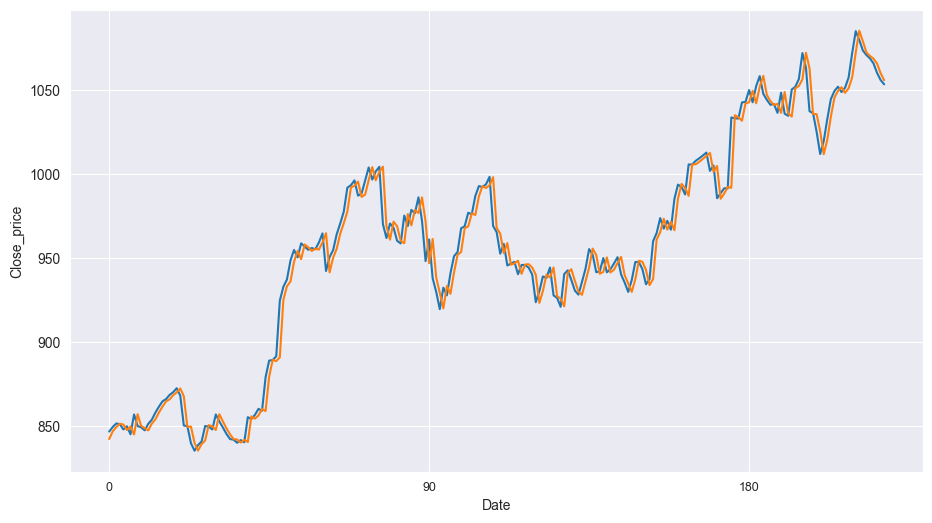

In [412]:
plt.figure(figsize= (11,6))
plt.plot(df['Close'].values[2800:])
plt.plot(predicts.values)
plt.xlabel('Date')
plt.ylabel('Close_price')
#plt.yticks(np.arange(test[2800:].min(), test[2800:].max(),40),size = 9)
plt.xticks([ i for i in range(0,len(df['Close'][2800:]),90) ], size = 9)

In [362]:
mean_absolute_error(test.values[:50],predicts)

20.620920866785074